In [383]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

import optuna

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

In [384]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [385]:
df.shape

(1338, 7)

In [386]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [387]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [388]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [389]:
df.duplicated().sum()

np.int64(1)

In [390]:
duplicate_mask = df.duplicated(keep=False)
df[duplicate_mask]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [391]:
df = df.drop_duplicates()

In [392]:
y = df['charges']
X = df.drop('charges', axis=1)

In [393]:
y.mean()

np.float64(13279.121486655948)

In [394]:
X.shape, y.shape

((1337, 6), (1337,))

In [395]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [396]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [397]:
log_y_train = y_train.map(lambda x: np.log(x))

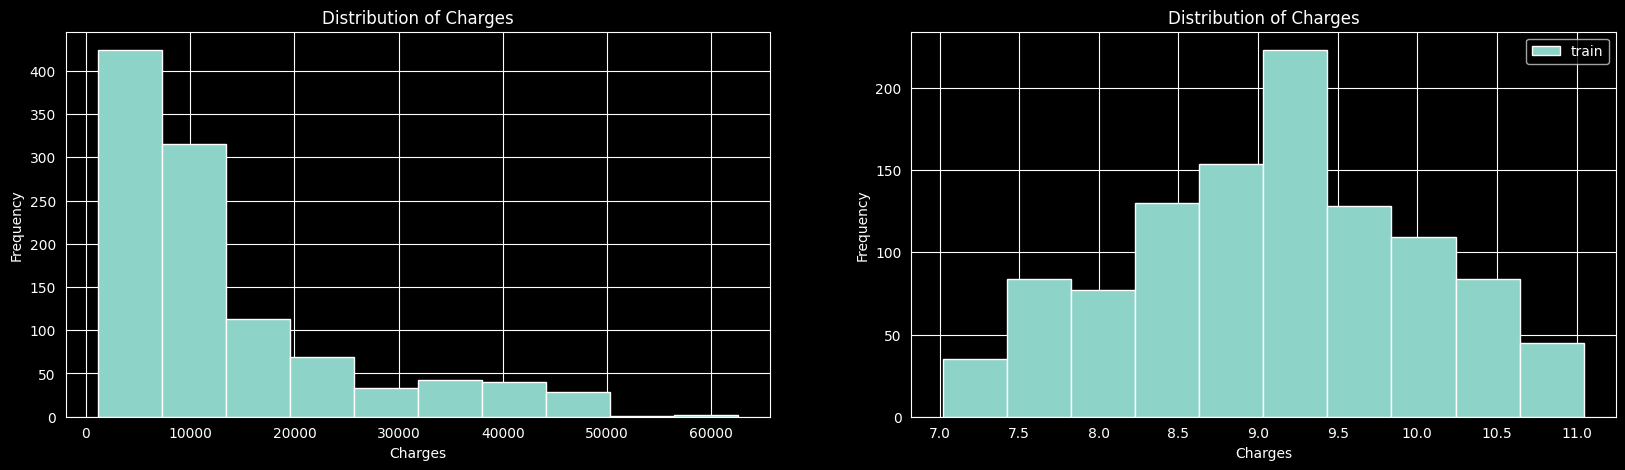

In [398]:
fig, ax = plt.subplots(1,2, figsize=(20,5))

ax[0].hist(y_train, bins=10, label='train')
ax[1].hist(log_y_train, bins=10, label='train')

ax[0].set_xlabel("Charges")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of Charges")

ax[1].set_xlabel("Charges")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Distribution of Charges")

plt.legend()
plt.show()


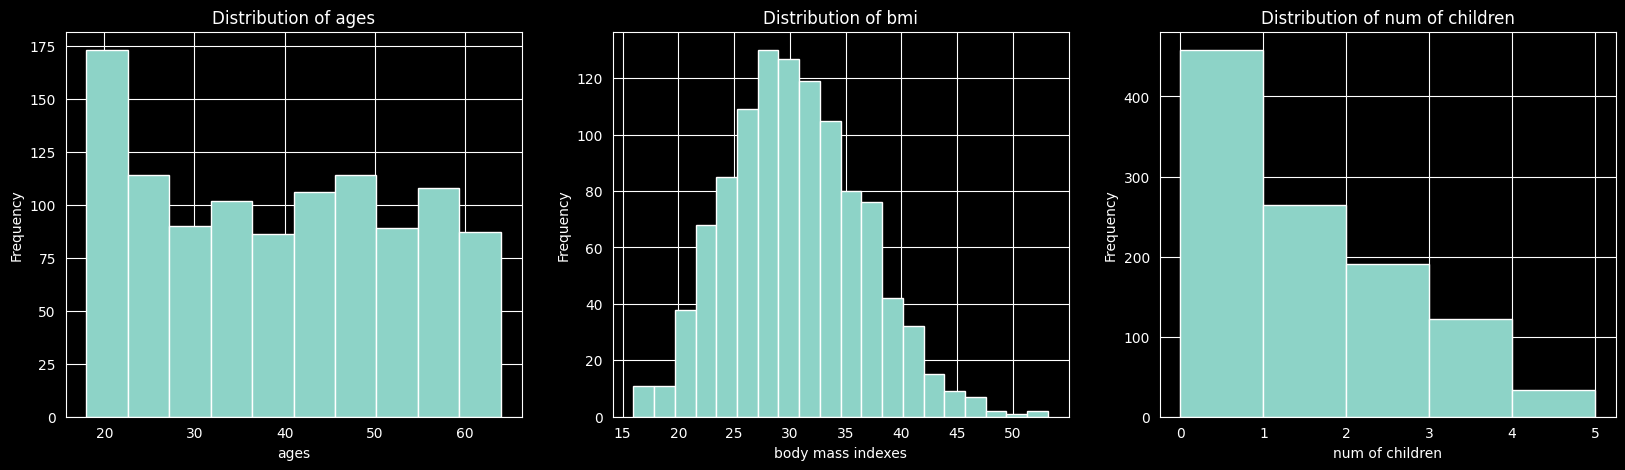

In [399]:
fig, axes = plt.subplots(1,3, figsize=(20,5))


axes[0].hist(X_train['age'], bins=10, label='train')
axes[0].set_xlabel("ages")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of ages")

axes[1].hist(X_train['bmi'], bins=20, label='train')
axes[1].set_xlabel("body mass indexes")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of bmi")

axes[2].hist(X_train['children'], bins=5, label='train')
axes[2].set_xlabel("num of children")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of num of children")



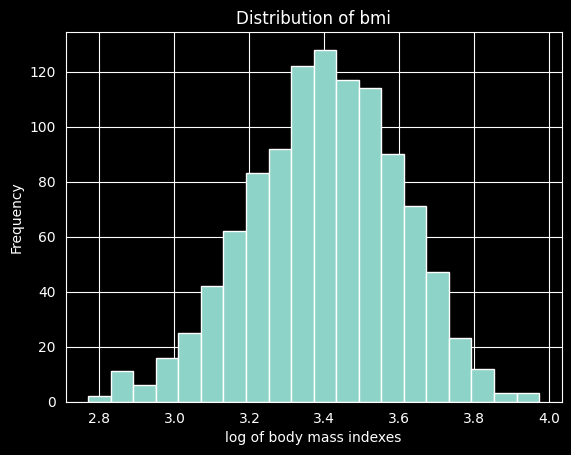

In [400]:
log_bmi = X_train['bmi'].map(lambda x: np.log(x))

plt.hist(log_bmi, bins=20, label='train')

plt.xlabel('log of body mass indexes')
plt.ylabel('Frequency')
plt.title("Distribution of bmi")
plt.show()

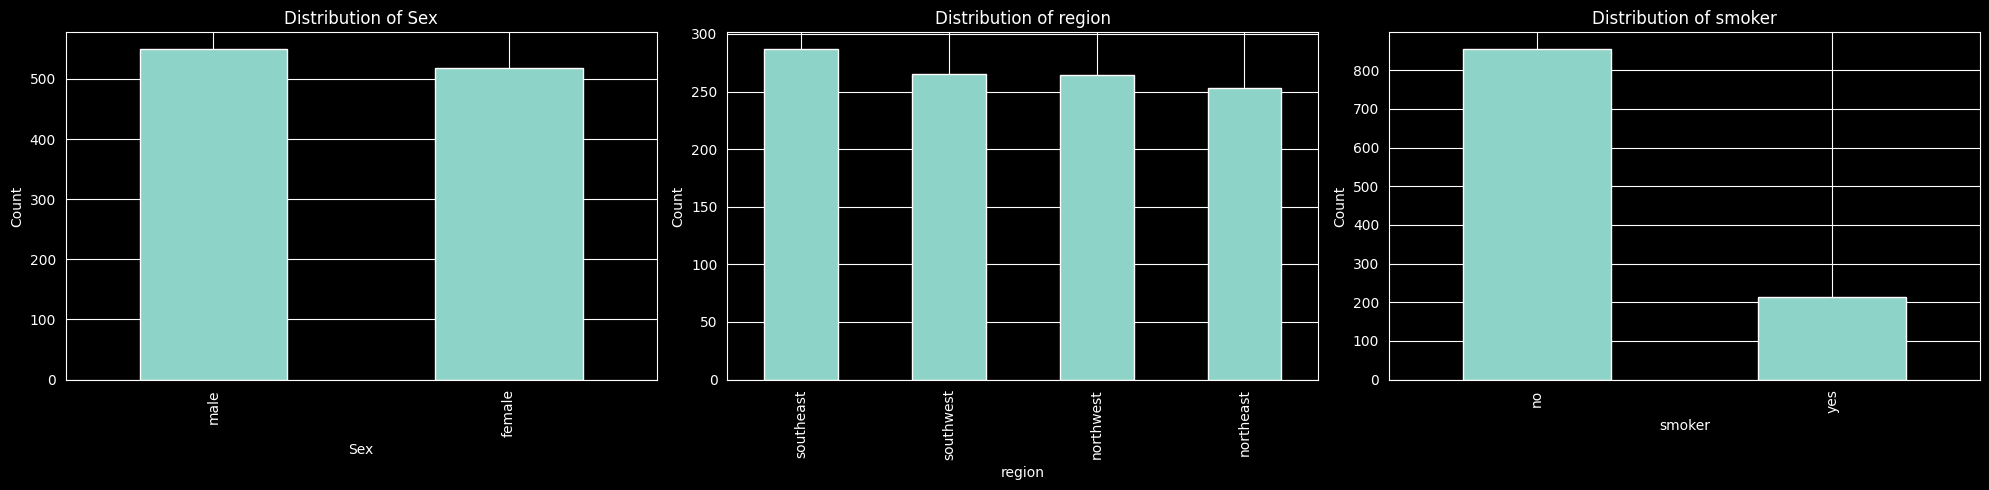

In [401]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

X_train['sex'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Sex")

X_train['region'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel("region")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of region")

X_train['smoker'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_xlabel("smoker")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of smoker")

plt.tight_layout()
plt.show()

In [402]:

enc = OneHotEncoder()

X_train_cat_encoded = enc.fit_transform(X_train[['sex', 'region', 'smoker']])
X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded.toarray(), columns=enc.get_feature_names_out(['sex', 'region', 'smoker']))

In [403]:
X_train_cat_encoded.head()


,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [404]:
X_train = pd.concat([X_train, X_train_cat_encoded], axis=1)


In [405]:
X_train.drop(['sex', 'region', 'smoker'], axis=1, inplace=True)
X_train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [406]:
y_train.shape, X_train.shape

((1069,), (1069, 11))

In [407]:
df_encoded = pd.concat([X_train, y_train], axis=1)

In [408]:
df_encoded.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2396.09590
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3279.86855
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,33471.97189
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,13405.39030
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9715.84100


In [409]:
corr_matrix = df_encoded.corr()

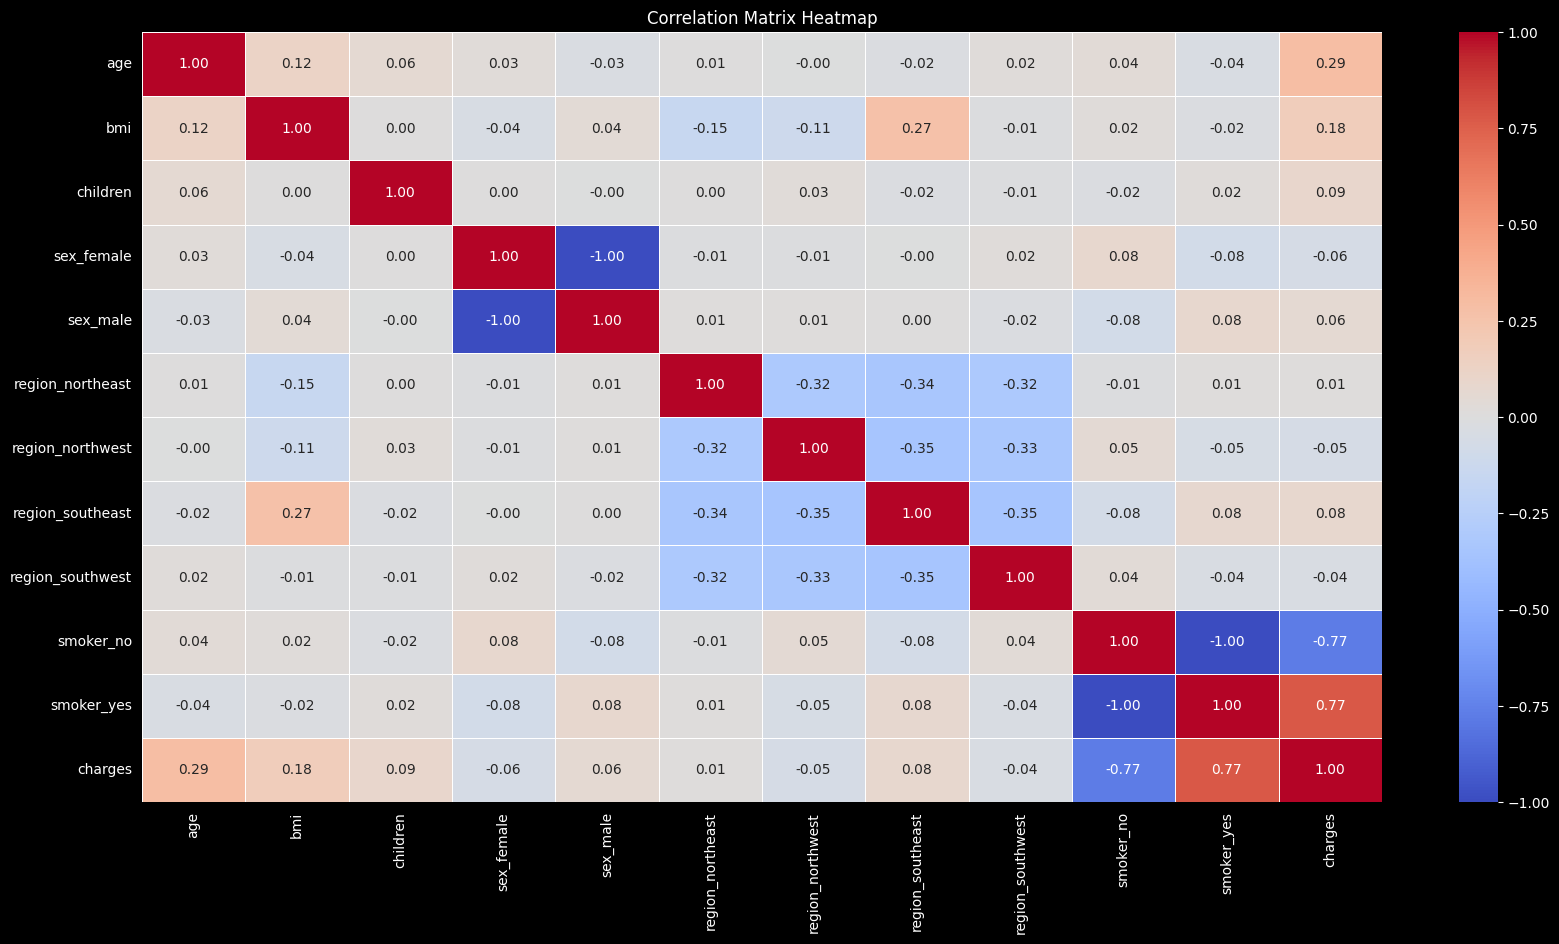

In [410]:
plt.figure(figsize=(20,10))
sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm",vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [411]:
df_encoded.describe()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges
count,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000
mean,39.198316,30.540426,1.084191,0.485500,0.514500,0.236670,0.246960,0.268475,0.247895,0.799813,0.200187,13030.203369
std,13.998594,6.051841,1.194723,0.500024,0.500024,0.425237,0.431445,0.443374,0.431993,0.400328,0.400328,11706.530971
min,18.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,26.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4747.052900
50%,39.000000,30.200000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,9290.139500
75%,51.000000,34.430000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,16450.894700
max,64.000000,53.130000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,62592.873090


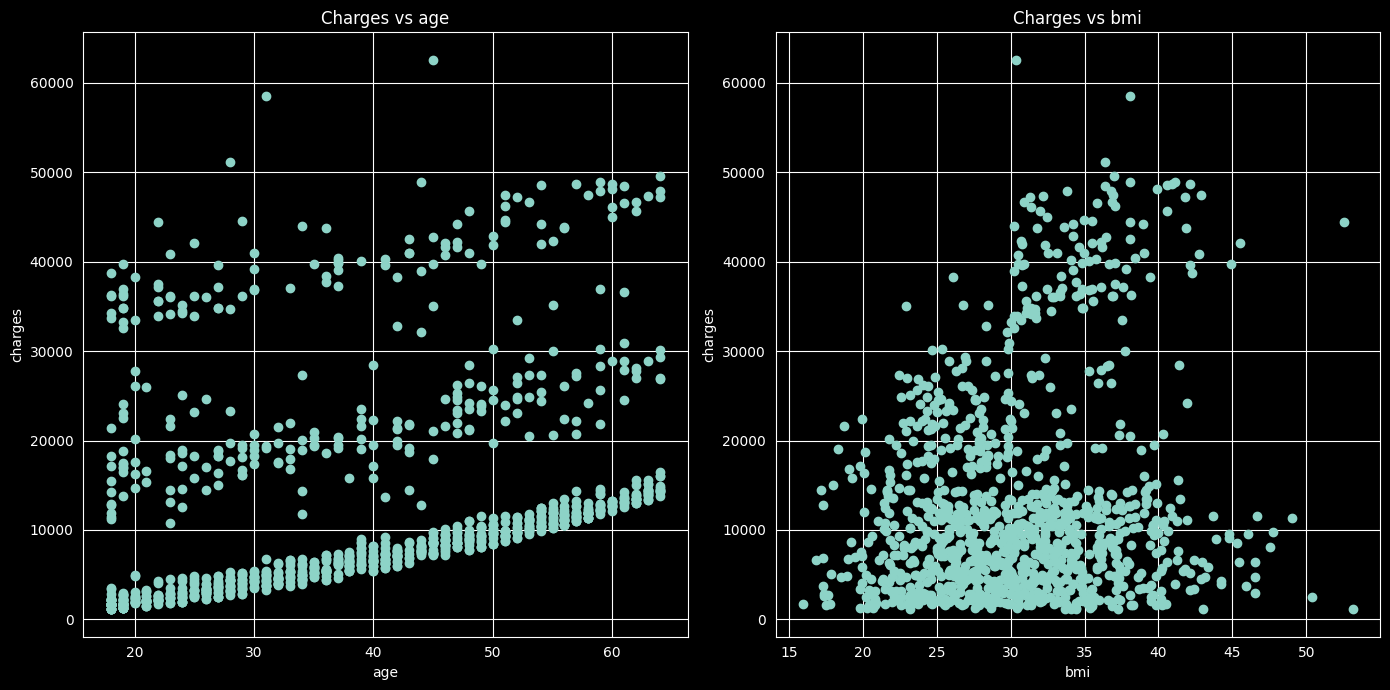

In [412]:
fig, ax = plt.subplots(1,2,figsize=(14,7))


ax[0].scatter(df_encoded['age'], df_encoded['charges'])
ax[0].set_xlabel('age')
ax[0].set_ylabel('charges')
ax[0].set_title('Charges vs age')

ax[1].scatter(df_encoded['bmi'], df_encoded['charges'])
ax[1].set_xlabel('bmi')
ax[1].set_ylabel('charges')
ax[1].set_title("Charges vs bmi")

plt.tight_layout()


In [413]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


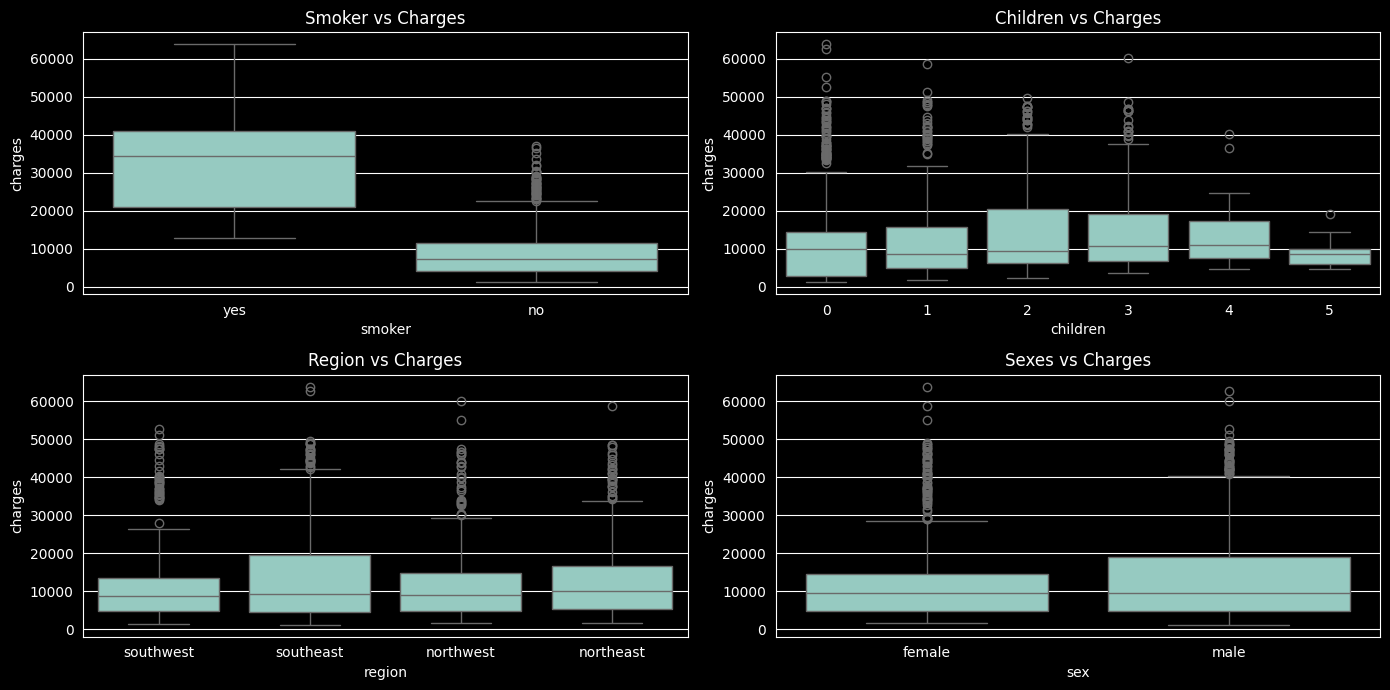

In [414]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

sns.boxplot(x='smoker', y='charges', data=df, ax=ax[0,0])
ax[0,0].set_title('Smoker vs Charges')

sns.boxplot(x='children', y='charges', data=df, ax=ax[0,1])
ax[0,1].set_title('Children vs Charges')

sns.boxplot(x='region', y='charges', data=df, ax=ax[1,0])
ax[1,0].set_title('Region vs Charges')

sns.boxplot(x='sex', y='charges', data=df, ax=ax[1,1])
ax[1,1].set_title('Sexes vs Charges')

plt.tight_layout()
plt.show()

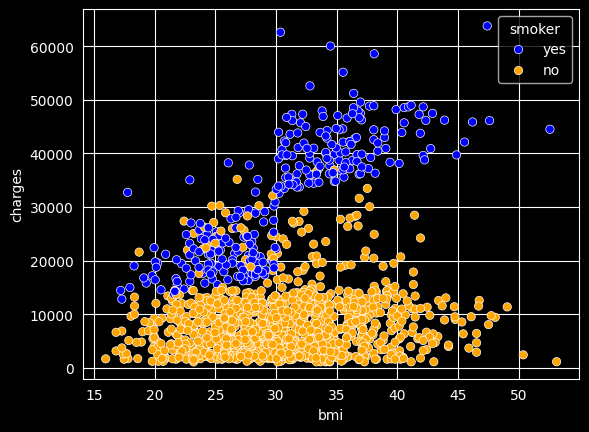

In [415]:
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',    palette=['blue', 'orange'])

In [416]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


upper, lower

(np.float64(34524.777625), np.float64(-13120.716174999998))

In [417]:
df_statistical_outliers = df[(df['charges']>upper) | (df['charges']<lower)]

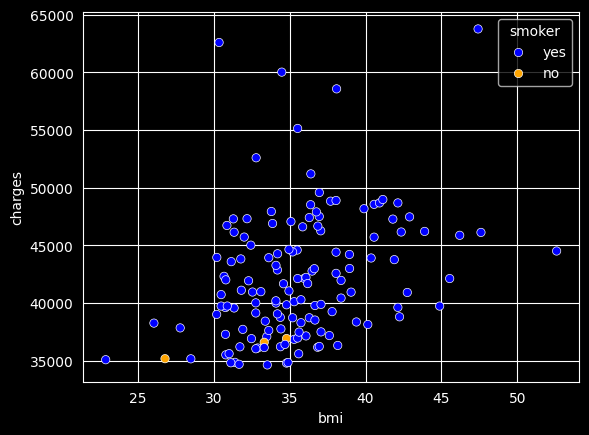

In [418]:
sns.scatterplot(data=df_statistical_outliers, x='bmi', y='charges', hue='smoker',    palette=['blue', 'orange'])


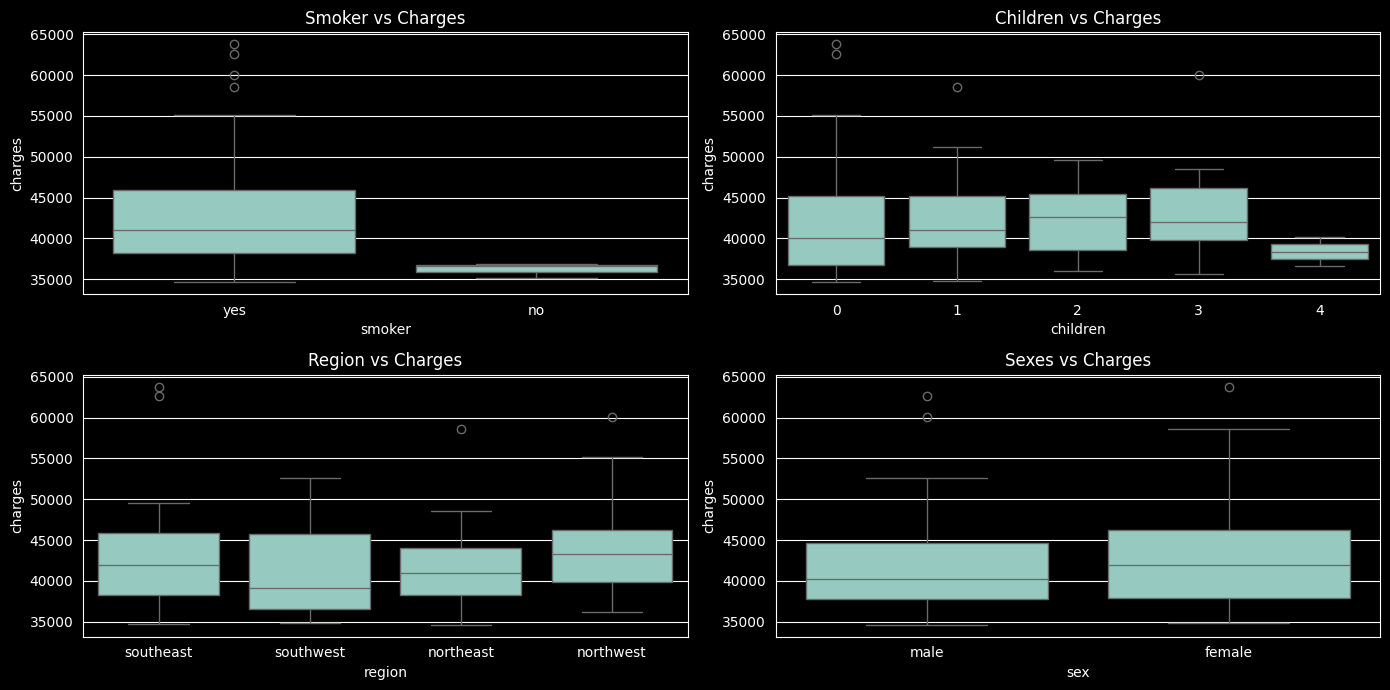

In [419]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

sns.boxplot(x='smoker', y='charges', data=df_statistical_outliers, ax=ax[0,0])
ax[0,0].set_title('Smoker vs Charges')

sns.boxplot(x='children', y='charges', data=df_statistical_outliers, ax=ax[0,1])
ax[0,1].set_title('Children vs Charges')

sns.boxplot(x='region', y='charges', data=df_statistical_outliers, ax=ax[1,0])
ax[1,0].set_title('Region vs Charges')

sns.boxplot(x='sex', y='charges', data=df_statistical_outliers, ax=ax[1,1])
ax[1,1].set_title('Sexes vs Charges')

plt.tight_layout()
plt.show()

In [420]:
df['bmi'][df['smoker']=='yes'].mode(), df['bmi'][df['smoker']=='no'].mode()


(0    28.31
 Name: bmi, dtype: float64,
 0    32.3
 Name: bmi, dtype: float64)

In [421]:
train = df_encoded.copy()

In [422]:
def bmi_category(bmi):
    if bmi<18.5:
        return "underweight"
    elif bmi<25:
        return "normal"
    elif bmi<30:
        return "overweight"
    else:
        return "obese"


train['bmi_category'] = train['bmi'].apply(bmi_category)
train['smoker_age'] = train['smoker_yes'] * train['age']
train['bmi_smoker'] = train['bmi'] * train['smoker_yes']
train['age_group'] = pd.cut(train['age'], bins=[18,30,45,60,100], labels=['18_30', '30_45', '45_60', '60_100'], include_lowest=True)

In [423]:
train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges,bmi_category,smoker_age,bmi_smoker,age_group
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2396.09590,normal,0.0,0.0,18_30
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3279.86855,overweight,0.0,0.0,18_30
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,33471.97189,obese,0.0,0.0,45_60
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,13405.39030,obese,0.0,0.0,60_100
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9715.84100,overweight,0.0,0.0,45_60


In [424]:
enc = OneHotEncoder()

train_encoded = enc.fit_transform(train[['bmi_category']])
train_encoded = pd.DataFrame(train_encoded.toarray(), columns=enc.get_feature_names_out(['bmi_category']))

train = pd.concat([train, train_encoded], axis=1)

In [425]:
train.drop('bmi_category', axis=1, inplace=True)

In [426]:
train = pd.get_dummies(train, columns=['age_group'], drop_first=False)

In [427]:
y_col = train.pop('charges')
train.insert(len(train.columns), 'charges', y_col)
train['log_charges'] = log_y_train

In [428]:
train.columns

Index(['age', 'bmi', 'children', 'sex_female', 'sex_male', 'region_northeast',
       'region_northwest', 'region_southeast', 'region_southwest', 'smoker_no',
       'smoker_yes', 'smoker_age', 'bmi_smoker', 'bmi_category_normal',
       'bmi_category_obese', 'bmi_category_overweight',
       'bmi_category_underweight', 'age_group_18_30', 'age_group_30_45',
       'age_group_45_60', 'age_group_60_100', 'charges', 'log_charges'],
      dtype='str')

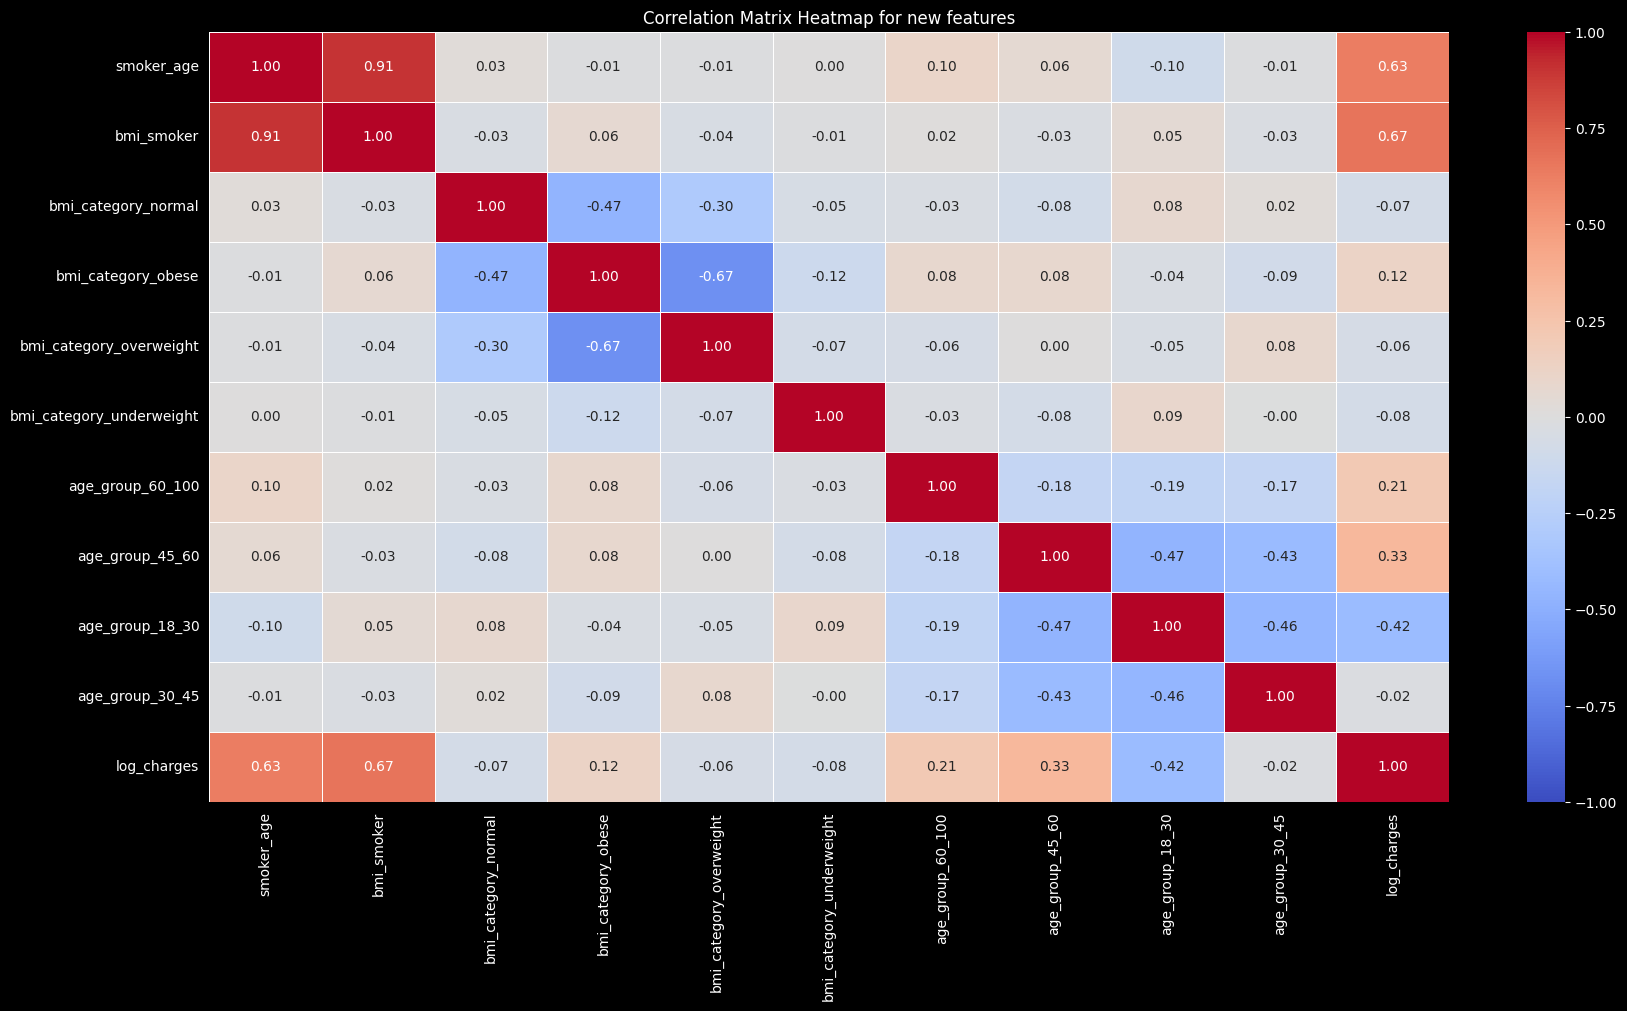

In [429]:
plt.figure(figsize=(20,10))
sns.heatmap(data=train[['smoker_age', 'bmi_smoker', 'bmi_category_normal',
       'bmi_category_obese', 'bmi_category_overweight',
       'bmi_category_underweight', 'age_group_60_100', 'age_group_45_60',
       'age_group_18_30', 'age_group_30_45', 'log_charges']].corr(), annot=True, cmap="coolwarm",vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap for new features')
plt.show()

In [430]:
train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,...,bmi_category_normal,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_18_30,age_group_30_45,age_group_45_60,age_group_60_100,charges,log_charges
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,True,False,False,False,2396.09590,7.781596
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,True,False,False,False,3279.86855,8.095559
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,False,False,True,False,33471.97189,10.418464
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,False,False,False,True,13405.39030,9.503412
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,False,False,True,False,9715.84100,9.181513


In [431]:
cols = ['age_group_18_30', 'age_group_30_45', 'age_group_45_60', 'age_group_60_100']
train[cols] = train[cols].astype(int)

In [432]:
X_train = train.drop(columns=['charges','log_charges'])
X_train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,...,smoker_age,bmi_smoker,bmi_category_normal,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_18_30,age_group_30_45,age_group_45_60,age_group_60_100
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,0
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0


In [433]:
y_train = train['log_charges']

### Preprocessing for the test data

In [434]:
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [435]:
log_y_test = y_test.map(lambda x: np.log(x))

In [436]:
enc = OneHotEncoder()

X_test_cat_encoded = enc.fit_transform(X_test[['sex', 'region', 'smoker']])
X_test_cat_encoded = pd.DataFrame(X_test_cat_encoded.toarray(), columns=enc.get_feature_names_out(['sex', 'region', 'smoker']))

In [437]:
X_test = pd.concat([X_test, X_test_cat_encoded], axis=1)


In [438]:
X_test.drop(['sex', 'region', 'smoker'], axis=1, inplace=True)
X_test.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,49,22.515,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,29,25.600,4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,51,36.385,3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,31,34.390,3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,31,38.390,2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [439]:
X_test['bmi_category'] = X_test['bmi'].apply(bmi_category)
X_test['smoker_age'] = X_test['smoker_yes'] * X_test['age']
X_test['bmi_smoker'] = X_test['bmi'] * X_test['smoker_yes']
X_test['age_group'] = pd.cut(X_test['age'], bins=[18,30,45,60,100], labels=['18_30', '30_45', '45_60', '60_100'], include_lowest=True)

In [440]:
X_test.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,bmi_category,smoker_age,bmi_smoker,age_group
0,49,22.515,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,normal,0.0,0.00,45_60
1,29,25.600,4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,overweight,0.0,0.00,18_30
2,51,36.385,3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,obese,0.0,0.00,45_60
3,31,34.390,3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,obese,31.0,34.39,30_45
4,31,38.390,2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,obese,0.0,0.00,30_45


In [441]:
enc = OneHotEncoder()

test_encoded = enc.fit_transform(X_test[['bmi_category']])
test_encoded = pd.DataFrame(test_encoded.toarray(), columns=enc.get_feature_names_out(['bmi_category']))

X_test = pd.concat([X_test, test_encoded], axis=1)

In [442]:
X_test.drop('bmi_category', axis=1, inplace=True)

In [443]:
X_test = pd.get_dummies(X_test, columns=['age_group'], drop_first=False)


In [444]:
cols = ['age_group_18_30', 'age_group_30_45', 'age_group_45_60', 'age_group_60_100']
X_test[cols] = X_test[cols].astype(int)

In [445]:
X_test.shape, train.shape

((268, 21), (1069, 23))

## Scaling the train dataset

In [446]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,...,smoker_age,bmi_smoker,bmi_category_normal,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_18_30,age_group_30_45,age_group_45_60,age_group_60_100
0,-1.157680,-0.996928,-0.907908,-0.971409,0.971409,1.795911,-0.572669,-0.605812,-0.57411,0.500292,...,-0.462805,-0.487883,2.185950,-1.035232,-0.649263,-0.115196,1.415206,-0.646353,-0.663853,-0.266725
1,-1.300619,-0.792762,0.766904,-0.971409,0.971409,1.795911,-0.572669,-0.605812,-0.57411,0.500292,...,-0.462805,-0.487883,-0.457467,-1.035232,1.540208,-0.115196,1.415206,-0.646353,-0.663853,-0.266725
2,0.914926,1.154664,0.766904,1.029432,-1.029432,-0.556820,1.746208,-0.605812,-0.57411,0.500292,...,-0.462805,-0.487883,-0.457467,0.965967,-0.649263,-0.115196,-0.706611,-0.646353,1.506358,-0.266725
3,1.701087,1.806837,-0.907908,-0.971409,0.971409,-0.556820,-0.572669,1.650678,-0.57411,0.500292,...,-0.462805,-0.487883,-0.457467,0.965967,-0.649263,-0.115196,-0.706611,-0.646353,-0.663853,3.749178
4,0.557580,-0.651417,0.766904,1.029432,-1.029432,1.795911,-0.572669,-0.605812,-0.57411,0.500292,...,-0.462805,-0.487883,-0.457467,-1.035232,1.540208,-0.115196,-0.706611,-0.646353,1.506358,-0.266725


In [447]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_test.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,...,smoker_age,bmi_smoker,bmi_category_normal,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_18_30,age_group_30_45,age_group_45_60,age_group_60_100
0,0.700518,-1.326734,-0.907908,-0.971409,0.971409,1.795911,-0.572669,-0.605812,-0.574110,0.500292,...,-0.462805,-0.487883,2.185950,-1.035232,-0.649263,-0.115196,-0.706611,-0.646353,1.506358,-0.266725
1,-0.728865,-0.816733,2.441716,1.029432,-1.029432,-0.556820,-0.572669,-0.605812,1.741827,0.500292,...,-0.462805,-0.487883,-0.457467,-1.035232,1.540208,-0.115196,1.415206,-0.646353,-0.663853,-0.266725
2,0.843457,0.966203,1.604310,1.029432,-1.029432,-0.556820,1.746208,-0.605812,-0.574110,0.500292,...,-0.462805,-0.487883,-0.457467,0.965967,-0.649263,-0.115196,-0.706611,-0.646353,1.506358,-0.266725
3,-0.585927,0.636397,1.604310,-0.971409,0.971409,-0.556820,1.746208,-0.605812,-0.574110,-1.998831,...,1.417869,2.278622,-0.457467,0.965967,-0.649263,-0.115196,-0.706611,1.547143,-0.663853,-0.266725
4,-0.585927,1.297663,0.766904,-0.971409,0.971409,-0.556820,-0.572669,1.650678,-0.574110,0.500292,...,-0.462805,-0.487883,-0.457467,0.965967,-0.649263,-0.115196,-0.706611,1.547143,-0.663853,-0.266725


# Choosing the best models for data, to tune them later

In [448]:
baseline_models = [DecisionTreeRegressor(random_state=0),LinearRegression(),KNeighborsRegressor(), RandomForestRegressor(random_state=0), SVR(), XGBRegressor(), Lasso(), Ridge(), ElasticNet(), GradientBoostingRegressor(), AdaBoostRegressor()]


In [449]:
def compare_losses(model, X_train, y_train):
    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    return rmse, model.__class__.__name__


In [450]:
results = {}
for model in baseline_models:
    loss, name = compare_losses(model, X_train, y_train)
    results[name] = round(float(loss), 3)

In [451]:
sorted_results = sorted(results.items(), key=lambda x: x[1])
sorted_results

[('SVR', 0.387),
 ('GradientBoostingRegressor', 0.388),
 ('LinearRegression', 0.394),
 ('Ridge', 0.394),
 ('RandomForestRegressor', 0.404),
 ('XGBRegressor', 0.438),
 ('KNeighborsRegressor', 0.442),
 ('AdaBoostRegressor', 0.5),
 ('DecisionTreeRegressor', 0.512),
 ('ElasticNet', 0.854),
 ('Lasso', 0.908)]

### Hyperparameter Tuning

In [452]:
def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 1, 6)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 32)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 32)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)


    model = GradientBoostingRegressor(learning_rate=learning_rate,n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, subsample=subsample)

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

    return -score.mean()


In [453]:
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())

[I 2026-04-18 17:42:09,566] A new study created in memory with name: no-name-3d3ec31c-a2cd-4000-b1ca-f8ae0382b94a


In [454]:
# study.optimize(objective, n_trials=200)

In [455]:
# study.best_params

In [456]:
model_tuned_gradient_boost = GradientBoostingRegressor(learning_rate=0.019264803908200276,
                                        n_estimators=263,
                                        max_depth=3,
                                        min_samples_split=27,
                                        min_samples_leaf=6,
                                        subsample=0.9230000909086388)

In [457]:
loss, name = compare_losses(model_tuned_gradient_boost, X_train, y_train)
results[name] = round(float(loss), 3)

In [458]:
results['GradientBoostingRegressor']

0.376

In [459]:


def objective(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 1e3, log=True),
        "epsilon": trial.suggest_float("epsilon", 1e-3, 1.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-4, 1.0, log=True),
        "kernel": "rbf",
    }

    model = SVR(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    print(f'the score is: {score}')

    return -score.mean()

In [460]:

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler()
)

[I 2026-04-18 17:42:11,259] A new study created in memory with name: no-name-1ae6dc25-092d-417b-a8f1-03b4674b040c


In [461]:
# study.optimize(objective, n_trials=200)

In [462]:
# study.best_params


In [463]:
model_tuned_svr = SVR(C=586.7663030911493,
                  epsilon = 0.1317204057245302,
                  gamma=0.0019308298917663442)

In [464]:
loss, name = compare_losses(model_tuned_svr, X_train, y_train)
results[name] = round(float(loss), 3)

In [465]:
results['SVR']


0.377

Because svm is simpler model we will choose that one, but out of interest will check for the gradient boosting as well.

In [466]:
X_test.shape, X_train.shape

((268, 21), (1069, 21))

In [467]:
y_train.mean(), log_y_test.mean()

(np.float64(9.091616304623905), np.float64(9.133079721061554))

In [468]:
model_tuned_svr.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.0019308298917663442
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",586.7663030911493
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1317204057245302
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [469]:
y_pred_log = model_tuned_svr.predict(X_test)

In [470]:
y_pred = np.exp(y_pred_log)
y_true = np.exp(log_y_test)

log_rmse_svr = root_mean_squared_error(log_y_test, y_pred_log)
rmse_svr = root_mean_squared_error(y_true, y_pred)

In [471]:
rmse_svr, log_rmse_svr

(4277.85492565267, 0.31227291665122603)

In [472]:
model_tuned_gradient_boost.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.019264803908200276
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",263
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9230000909086388
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",27
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",6
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is 

In [473]:
y_pred_log = model_tuned_gradient_boost.predict(X_test)

In [474]:
y_pred = np.exp(y_pred_log)
y_true = np.exp(log_y_test)

log_rmse_gradient_boost = root_mean_squared_error(log_y_test, y_pred_log)
rmse_gradient_boost = root_mean_squared_error(y_true, y_pred)

In [475]:
rmse_gradient_boost, log_rmse_gradient_boost

(4377.334858969805, 0.32395842632963573)